In [2]:
import pandas as pd

matches = pd.read_csv("../data/raw/matches.csv")
deliveries = pd.read_csv("../data/raw/deliveries.csv")

print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape)

Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


In [3]:
print("===== MATCHES DATASET =====")
matches.info()

print("\n===== DELIVERIES DATASET =====")
deliveries.info()

===== MATCHES DATASET =====
<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 1

In [4]:
matches.isnull().sum().sort_values(ascending=False)

method             1074
city                 51
result_margin        19
player_of_match       5
winner                5
target_runs           3
target_overs          3
id                    0
date                  0
season                0
venue                 0
match_type            0
toss_decision         0
toss_winner           0
team2                 0
team1                 0
result                0
super_over            0
umpire1               0
umpire2               0
dtype: int64

In [5]:
deliveries.isnull().sum().sort_values(ascending=False)

fielder             251566
dismissal_kind      247970
player_dismissed    247970
extras_type         246795
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
non_striker              0
bowler                   0
batter                   0
ball                     0
total_runs               0
extra_runs               0
batsman_runs             0
is_wicket                0
dtype: int64

In [6]:
matches["winner"].value_counts().head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

In [7]:
toss_match_win = (
    matches["toss_winner"] == matches["winner"]
).sum()

total_completed_matches = matches["winner"].notna().sum()

percentage = (
    toss_match_win /
    total_completed_matches
) * 100

print(
    f"Toss winner won the match {percentage:.2f}% of the time."
)

Toss winner won the match 50.83% of the time.


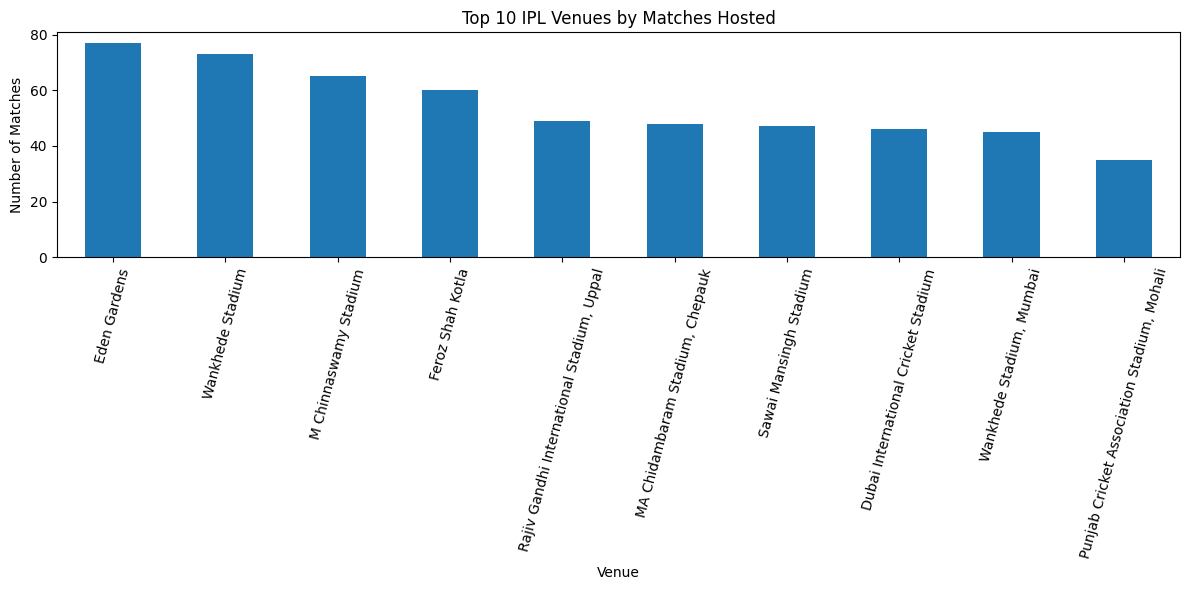

In [8]:
import matplotlib.pyplot as plt

top_venues = matches["venue"].value_counts().head(10)

plt.figure(figsize=(12,6))

top_venues.plot(kind="bar")

plt.title("Top 10 IPL Venues by Matches Hosted")
plt.xlabel("Venue")
plt.ylabel("Number of Matches")

plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig(
    "../reports/top_venues.png",
    bbox_inches="tight"
)

plt.show()

In [9]:
matches["venue"].value_counts().head(10)

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

In [10]:
processed_df = pd.read_csv(
    "../data/processed/processed_matches.csv"
)

processed_df.head()

,team1,team2,toss_winner,toss_decision,venue,city,winner
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings
2,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi,Delhi Daredevils
3,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Mumbai,Royal Challengers Bangalore
4,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Eden Gardens,Kolkata,Kolkata Knight Riders


In [11]:
processed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   team1          1090 non-null   str  
 1   team2          1090 non-null   str  
 2   toss_winner    1090 non-null   str  
 3   toss_decision  1090 non-null   str  
 4   venue          1090 non-null   str  
 5   city           1090 non-null   str  
 6   winner         1090 non-null   str  
dtypes: str(7)
memory usage: 177.8 KB
